# Evaluate models in `/models`

This notebook loads every saved model from the `/models` folder, runs inference on a test set, and plots ROC curves with AUC scores.

**Before running:**
- Place your model checkpoints in `./models` (relative to the repo root).
- Set the dataset paths in the configuration cell below.
- Ensure your data is preprocessed into `.npy` arrays if you use the custom loader.


In [16]:
from pathlib import Path

# --- Configuration ---
MODELS_DIR = Path("models")

# Model hyperparameters (must match the checkpoints)
WIN_SIZE = 100
INPUT_C = 15
OUTPUT_C = 15
BATCH_SIZE = 256

# Dataset selection: one of {"SMD", "MSL", "SMAP", "PSM", "custom"}
DATASET = "custom"
DATA_PATH = Path("path/to/dataset_root")  # used for built-in datasets

# Custom dataset (.npy arrays)
CUSTOM_TRAIN_PATH = Path("turbine_data/t2_wavelets/train.npy")
CUSTOM_TEST_PATH = Path("turbine_data/t2_wavelets/test.npy")
CUSTOM_LABELS_PATH = Path("turbine_data/t2_wavelets/test_labels.npy")


In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import roc_curve, auc

from model.AnomalyTransformer import AnomalyTransformer
from data_factory.data_loader import CustomLoader, get_loader_segment

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [7]:
def build_test_loader():
    if DATASET.lower() == "custom":
        missing = [p for p in (CUSTOM_TRAIN_PATH, CUSTOM_TEST_PATH, CUSTOM_LABELS_PATH) if not p.exists()]
        if missing:
            raise FileNotFoundError(f"Missing custom dataset files: {missing}")
        dataset = CustomLoader(
            data_path_train=str(CUSTOM_TRAIN_PATH),
            data_path_test=str(CUSTOM_TEST_PATH),
            data_path_test_labels=str(CUSTOM_LABELS_PATH),
            win_size=WIN_SIZE,
            step=1,
            mode="test",
        )
        return torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    return get_loader_segment(
        data_path=str(DATA_PATH),
        batch_size=BATCH_SIZE,
        win_size=WIN_SIZE,
        step=1,
        mode="test",
        dataset=DATASET,
    )

def load_checkpoint(path: Path) -> dict:
    checkpoint = torch.load(path, map_location=DEVICE)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint["state_dict"]
    return checkpoint

@torch.no_grad()
def compute_scores_labels(model, loader):
    model.eval()
    scores = []
    labels = []
    mse = torch.nn.MSELoss(reduction="none")
    for batch in loader:
        if isinstance(batch, (list, tuple)):
            inputs, batch_labels = batch
        else:
            raise ValueError("Expected loader to yield (inputs, labels) batches.")
        inputs = inputs.float().to(DEVICE)
        batch_labels = batch_labels.float()
        output, *_ = model(inputs)
        rec = mse(output, inputs).mean(dim=-1)
        scores.append(rec[:, -1].detach().cpu().numpy())
        if batch_labels.ndim == 3:
            batch_labels = batch_labels.squeeze(-1)
        labels.append(batch_labels[:, -1].detach().cpu().numpy())
    return np.concatenate(scores), np.concatenate(labels)

def evaluate_models():
    model_paths = sorted([
        p for p in MODELS_DIR.glob("**/*")
        if p.suffix in {".pth", ".pt", ".ckpt"}
    ])
    if not model_paths:
        raise FileNotFoundError(f"No model checkpoints found in {MODELS_DIR.resolve()}")

    loader = build_test_loader()
    results = []
    plt.figure(figsize=(8, 6))

    for path in model_paths:
        model = AnomalyTransformer(
            win_size=WIN_SIZE,
            enc_in=INPUT_C,
            c_out=OUTPUT_C,
            e_layers=3,
        ).to(DEVICE)
        model.load_state_dict(load_checkpoint(path), strict=False)
        scores, labels = compute_scores_labels(model, loader)
        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc = auc(fpr, tpr)
        results.append({"model": path.name, "auc": roc_auc})
        plt.plot(fpr, tpr, label=f"{path.name} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves for Models in /models")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return pd.DataFrame(results).sort_values(by="auc", ascending=False)


Total number of positive: 2433.0
Custom train: (10000, 15)
Custom test: (10000, 15)
Custom val: (10000, 15)
Custom test_labels: (10000,)


/tmp/ipykernel_19411/1298404045.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=DEVICE)


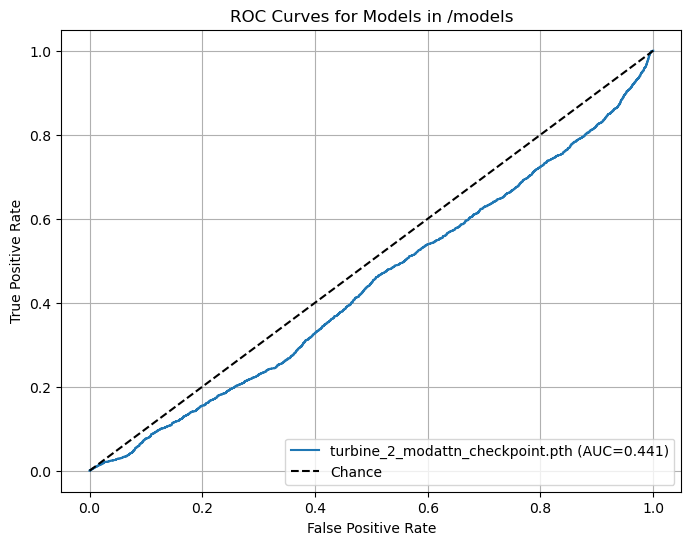

,model,auc
0,turbine_2_modattn_checkpoint.pth,0.440871


In [17]:
results = evaluate_models()
results
